## Simulating 10000 Future SpaceX stock prices 

In [2]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [4]:
# Load the Space X stock data
historical_data = yf.download(tickers='SPCX', start = '2026-06-12', end = '2026-07-11')

[*********************100%***********************]  1 of 1 completed


In [9]:
historical_data = historical_data.droplevel(1, 1)

In [10]:
historical_data

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-06-12,160.949997,176.520004,149.339996,150.000000,519234800
2026-06-15,192.500000,193.000000,168.350006,171.740005,256226600
2026-06-16,211.389999,225.639999,199.979996,200.509995,195401600
2026-06-17,191.820007,213.800003,187.009995,209.839996,201719500
2026-06-18,185.000000,190.000000,172.110001,188.389999,272126800
2026-06-22,154.600006,176.750000,154.000000,176.039993,169183800
2026-06-23,156.110001,165.500000,147.110001,151.059998,155848100
2026-06-24,154.539993,159.860001,150.720001,154.199997,76101500
2026-06-25,153.000000,160.649994,150.000000,156.630005,62212400


In [12]:
# Create the variables for our simulation
num_days = 252
num_simulations = 10000
dates = pd.date_range(start = historical_data.index[-1], periods = num_days + 1, freq = 'B')

In [13]:
# Calculate the start price
starting_price = historical_data['Close'].iloc[-1]
daily_returns = historical_data['Close'].pct_change().dropna()
# Calculate the mean price
mean = daily_returns.mean() * num_days
# Calculate the sigma 
sigma = daily_returns.std() * np.sqrt(num_days)

In [14]:
# Create a simulation array of all zeros
simulations = np.zeros((num_simulations, num_days))

# Show the simulations
simulations

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 252))

In [16]:
# Create the Monte Carlo Simulation for Space X
for i in range(num_simulations):
    daily_returns_simulated = np.random.normal(mean/num_days, sigma/np.sqrt(num_days), num_days)
    price_path = starting_price * np.cumprod(1+daily_returns_simulated)
    simulations[i, :] = price_path

In [17]:
# Show the simulations
simulations

array([[155.41198781, 138.18455139, 118.61101536, ...,  18.9756231 ,
         18.19962255,  17.71162147],
       [135.98981095, 158.65058079, 158.4001591 , ...,  14.30640445,
         14.34574099,  15.66153743],
       [140.74918443, 151.58324359, 149.82301004, ..., 564.03876389,
        582.5282886 , 549.74652668],
       ...,
       [159.17575462, 157.2932188 , 152.84900629, ..., 236.13613243,
        232.87269513, 223.74702174],
       [155.80704617, 186.88379705, 202.50268818, ...,  12.23960226,
         13.60321161,  14.38686373],
       [164.50526833, 173.62113033, 158.33603645, ...,  16.22806832,
         14.43503165,  15.29939671]], shape=(10000, 252))

In [18]:
# Calculate the expected mean price after the 252 trading days
expected_price = simulations[:, -1].mean()
print('Expected Price: ', expected_price)

Expected Price:  72.45617116567753


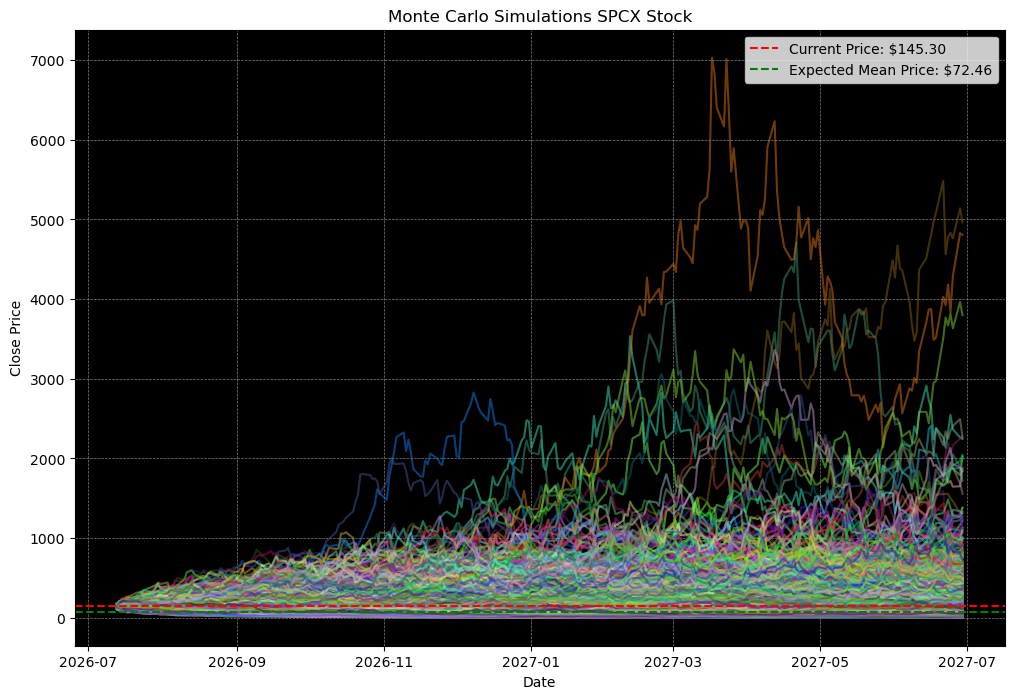

In [19]:
# Plot the simulations 
plt.figure(figsize=(12,8))
for i in range(num_simulations):
    plt.plot(dates[1:], simulations[i], alpha=0.5, color=np.random.rand(3,))

plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Monte Carlo Simulations SPCX Stock')
plt.axhline(starting_price, color='red', linestyle='--', label=f'Current Price: ${starting_price:.2f}')
plt.axhline(expected_price, color='green', linestyle='--', label=f'Expected Mean Price: ${expected_price:.2f}')
plt.gca().set_facecolor('black')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.tick_params(colors='black')
plt.legend()
plt.show()